In [2]:
import os
import random
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt

from src.ArtificialTrainDataGenerator import ArtificialTrainDataGenerator
from src.FeatureEnhancer import FeatureEnhancer
from src.Elements import Elements

N_SAMPLES = 250
SAMPLE_PER_ELEMENT = 3
SIGMA_RANGE = (0.2, 0.8)
MU_LOCAL_ERR = 0.05
MU_GLOBAL_ERR = 0.1
OUTPUT_DIR = "data/training_data/artificial"

X, y = ArtificialTrainDataGenerator.generate_dataset(
    N_SAMPLES,
    mu_local_err=MU_LOCAL_ERR,
    mu_global_err=MU_GLOBAL_ERR,
    sigma_range=SIGMA_RANGE,
    use_cache=False
)
print(y[0].tolist())


Generating Samples: 100%|██████████| 250/250 [00:00<00:00, 1290.67it/s]

[0.0, 285.17579109276204, 242.48960537520435, 0.0, 197.98071548517643, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 267.3966558228384, 0.0, 5.988567919266207]


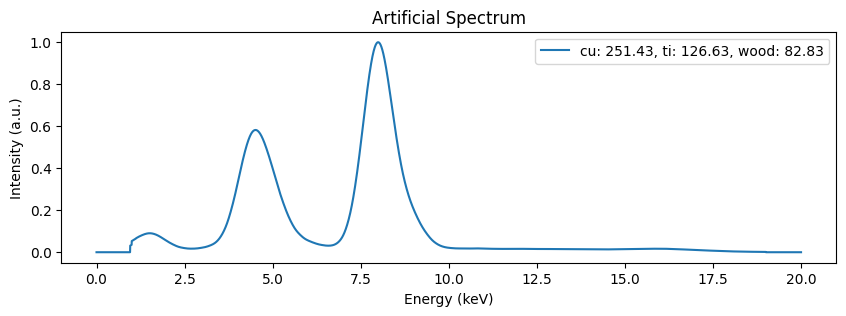

In [7]:
selected_index = np.random.randint(0, N_SAMPLES - 1)

plt.figure(figsize=(10, 3))
plt.plot(np.linspace(0, 20, 4096), X[selected_index], label=", ".join([f"{el[0]}: {round(el[1], 2)}" for el in zip(list(Elements.LINES.keys()) + ["wood"], y[selected_index]) if el[1] > 0]))
plt.title("Artificial Spectrum")
plt.xlabel("Energy (keV)")
plt.ylabel("Intensity (a.u.)")
plt.legend(loc="upper right")
plt.savefig("data/plots/artificial_spectrum_example.svg", bbox_inches='tight', pad_inches=0.1)

In [3]:
X = FeatureEnhancer.process_spectra(np.array(X))
y = y * (np.sum(X, axis=1) / np.sum(y, axis=1))[:, np.newaxis]


100%|██████████| 51/51 [00:00<00:00, 458050.33it/s]


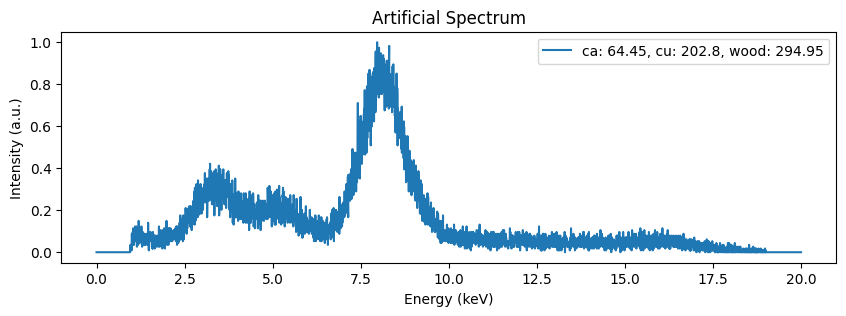

In [4]:
# y[selected_index] = y[selected_index] * (np.sum(X[selected_index]) / np.sum(y[selected_index]))
plt.figure(figsize=(10, 3))
plt.plot(np.linspace(0, 20, 4096), X[selected_index], label=", ".join([f"{el[0]}: {round(el[1], 2)}" for el in zip(list(Elements.LINES.keys()) + ["wood"], y[selected_index]) if el[1] > 0]))
plt.title("Artificial Spectrum")
plt.xlabel("Energy (keV)")
plt.ylabel("Intensity (a.u.)")
plt.legend(loc="upper right")
plt.savefig("data/plots/artificial_spectrum_example_noise.svg",bbox_inches='tight', pad_inches=0.1)


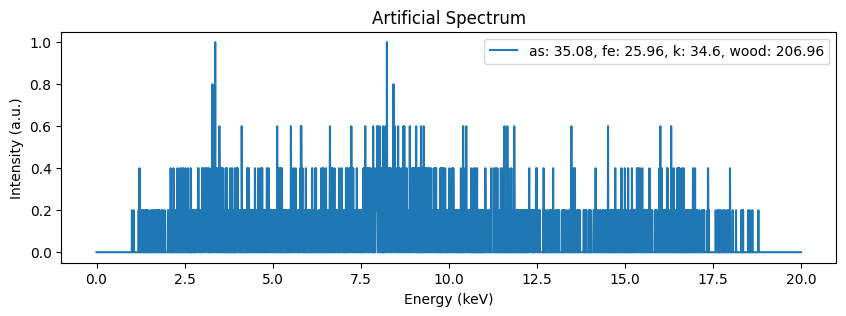

In [42]:
# y[selected_index] /= 4096
plt.figure(figsize=(10, 3))
plt.plot(np.linspace(0, 20, 4096), X[selected_index], label=", ".join([f"{el[0]}: {round(el[1], 2)}" for el in zip(list(Elements.LINES.keys()) + ["wood"], y[selected_index]) if el[1] > 0]))
plt.title("Artificial Spectrum")
plt.xlabel("Energy (keV)")
plt.ylabel("Intensity (a.u.)")
plt.legend(loc="upper right")
plt.savefig("data/plots/artificial_spectrum_example_noise_normalized.svg", bbox_inches='tight', pad_inches=0.1)

In [5]:
def save_data(X, y, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    np.save(os.path.join(output_dir, f"X_regression_{timestamp}.npy"), X)
    np.save(os.path.join(output_dir, f"y_regression_{timestamp}.npy"), y)
    print(f"Data saved in '{output_dir}' with timestamp {timestamp}")

save_data(X, y, OUTPUT_DIR)

Data saved in 'data/training_data/artificial' with timestamp 20250901_235041


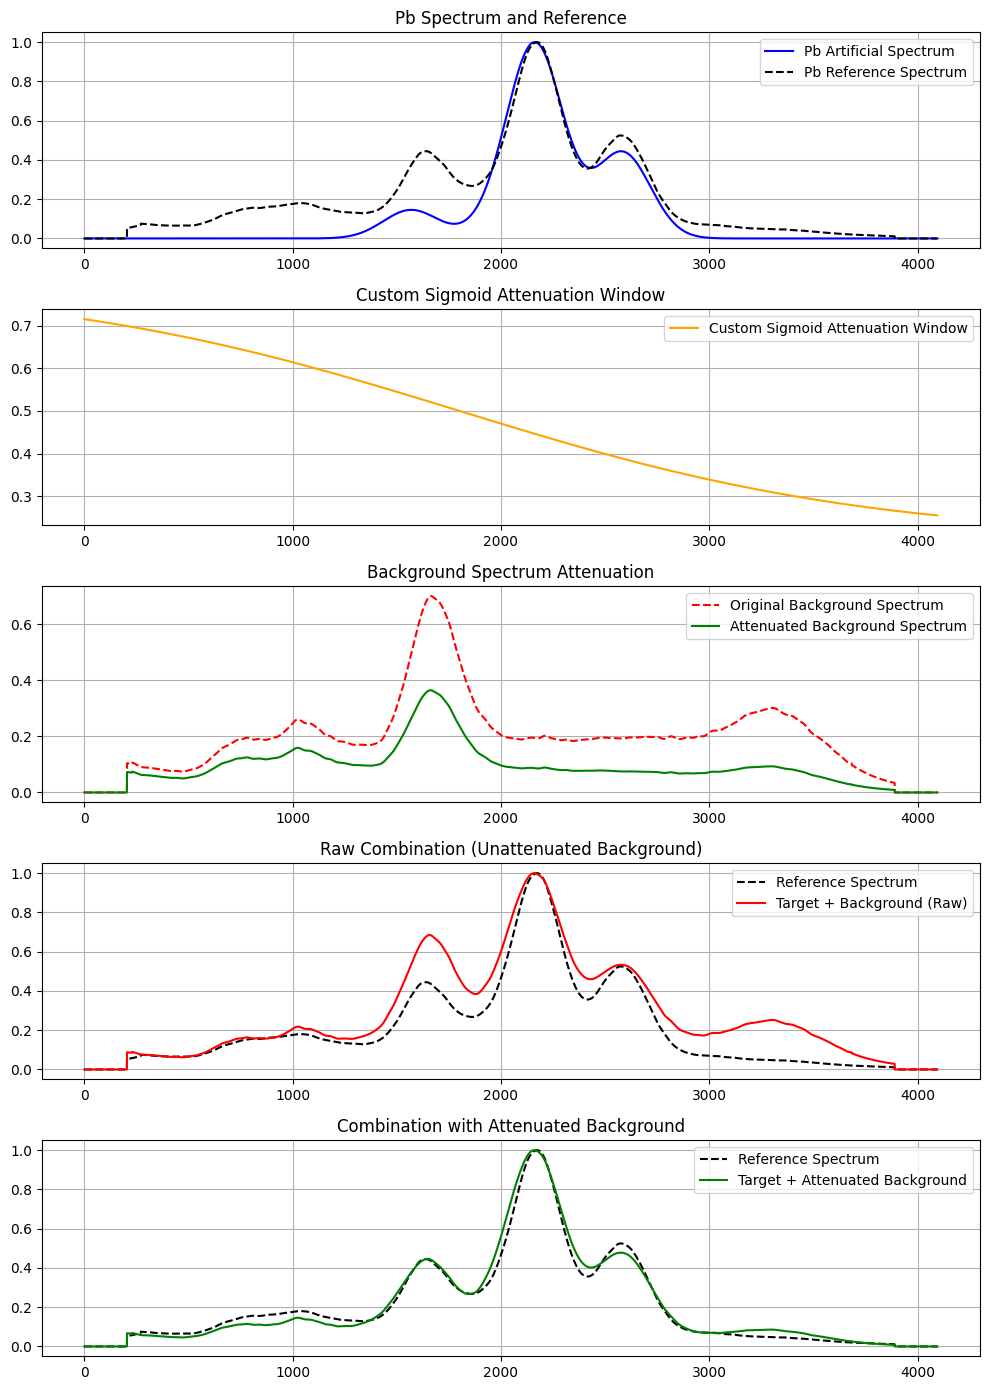

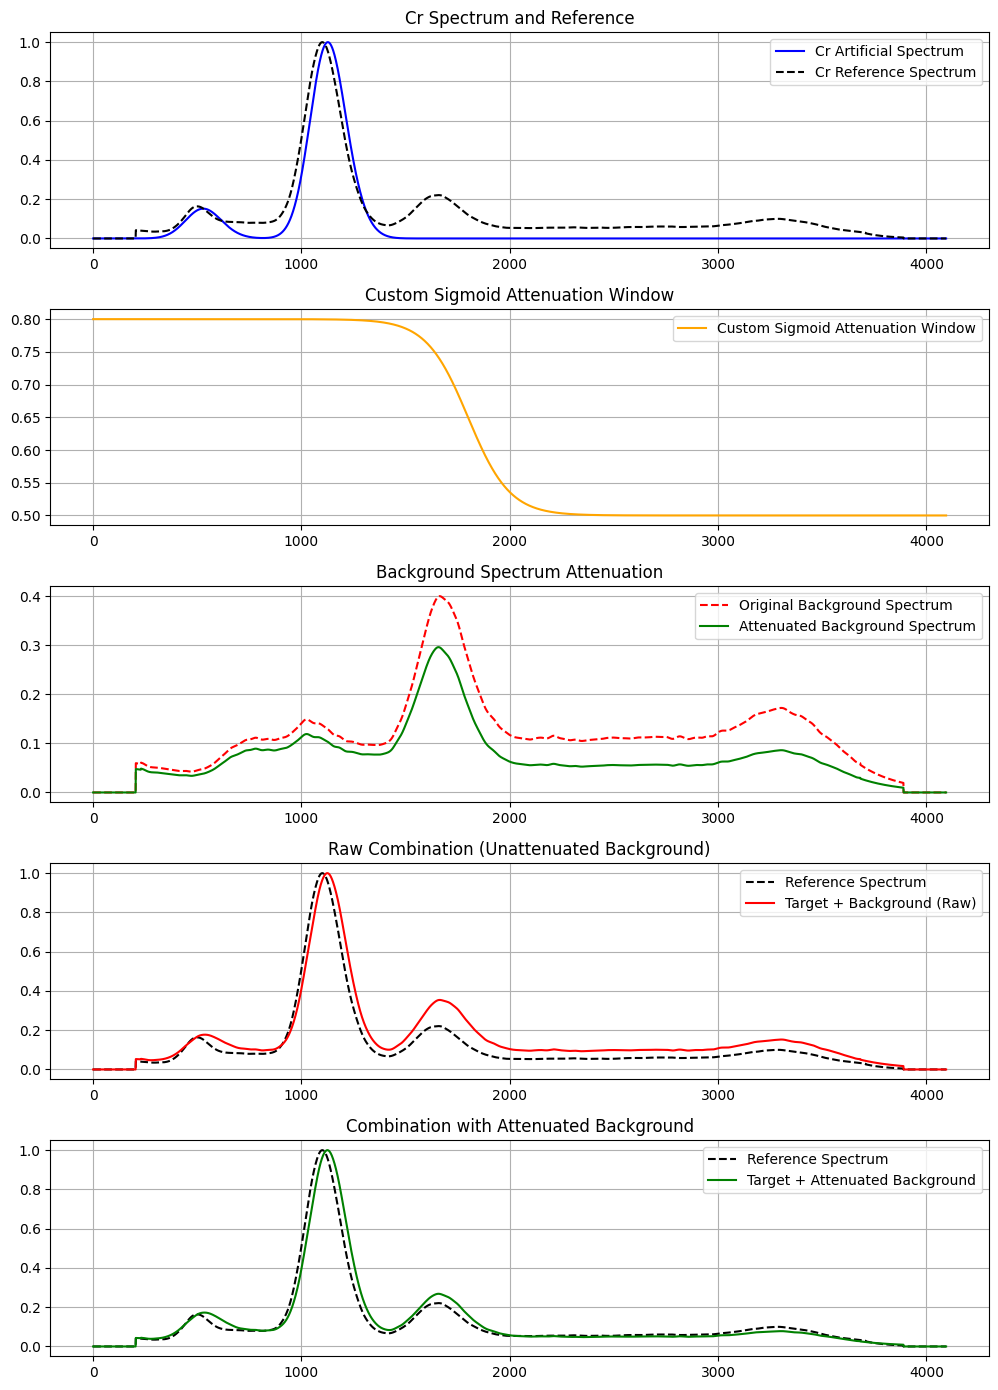

In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def custom_sigmoid_window(
    x: np.ndarray,
    center: float,
    steepness: float,
    left_max: float = 1.0,
    right_min: float = 0.0
) -> np.ndarray:
    """
    Creates a custom sigmoid attenuation window.

    Args:
        x: Array of channel indices.
        center: Center point of the sigmoid drop.
        steepness: Controls how sharp the transition is.
        left_max: Value on the left (low x).
        right_min: Value on the right (high x).

    Returns:
        A window array shaped like a smooth sigmoid.
    """
    return left_max - (left_max - right_min) * sigmoid(steepness * (x - center))


def plot_spectrum_components(
    target_spectrum,
    background_spectrum,
    reference_spectrum,
    element_label="Element",
    attenuation_strength=0.6,
    sigmoid_center=None,
    sigmoid_steepness=None,
    sigmoid_left_max=1.0,
    sigmoid_right_min=0.0
):
    num_channels = len(target_spectrum)
    channel_range = np.arange(num_channels)

    # Determine sigmoid window parameters
    if sigmoid_center is None:
        sigmoid_center = np.argmax(target_spectrum)
    if sigmoid_steepness is None:
        attenuation_width = 4 * (num_channels / 20)
        sigmoid_steepness = 1 / attenuation_width

    sigmoid_window = custom_sigmoid_window(
        x=channel_range,
        center=sigmoid_center,
        steepness=sigmoid_steepness,
        left_max=sigmoid_left_max,
        right_min=sigmoid_right_min
    )

    original_background = background_spectrum * attenuation_strength
    attenuated_background = original_background * sigmoid_window

    combined_spectrum_raw = target_spectrum + original_background
    normalized_combined_raw = combined_spectrum_raw / np.max(combined_spectrum_raw)

    combined_spectrum_attenuated = target_spectrum + attenuated_background
    normalized_combined_attenuated = combined_spectrum_attenuated / np.max(combined_spectrum_attenuated)

    fig, axes = plt.subplots(5, 1, figsize=(10, 14), sharex=True)

    axes[0].plot(channel_range, target_spectrum, label=f'{element_label} Artificial Spectrum', color='blue')
    axes[0].plot(channel_range, reference_spectrum, linestyle='--', label=f'{element_label} Reference Spectrum', color='black')
    axes[0].set_title(f'{element_label} Spectrum and Reference')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(channel_range, sigmoid_window, color='orange', label='Custom Sigmoid Attenuation Window')
    axes[1].set_title('Custom Sigmoid Attenuation Window')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(channel_range, original_background, color='red', linestyle='--', label='Original Background Spectrum')
    axes[2].plot(channel_range, attenuated_background, color='green', label='Attenuated Background Spectrum')
    axes[2].set_title('Background Spectrum Attenuation')
    axes[2].legend()
    axes[2].grid(True)

    axes[3].plot(channel_range, reference_spectrum, color='black', linestyle='--', label='Reference Spectrum')
    axes[3].plot(channel_range, normalized_combined_raw, color='red', label='Target + Background (Raw)')
    axes[3].set_title('Raw Combination (Unattenuated Background)')
    axes[3].legend()
    axes[3].grid(True)

    axes[4].plot(channel_range, reference_spectrum, color='black', linestyle='--', label='Reference Spectrum')
    axes[4].plot(channel_range, normalized_combined_attenuated, color='green', label='Target + Attenuated Background')
    axes[4].set_title('Combination with Attenuated Background')
    axes[4].legend()
    axes[4].grid(True)

    for ax in axes:
        ax.tick_params(labelbottom=True)
    

    plt.tight_layout()

wood_spectrum = np.load("data/objects/pigment_palette/pad_average_spectra_calibrated.npz", allow_pickle=True)["spectrum"].item()["wood"]

linspace = np.linspace(0, 20, 4096)
wood_spectrum = ArtificialTrainDataGenerator.generate_element_sample(
    linspace, "wood", sigma=0.65, mu_global_err=0.05, mu_local_err=0.05, use_cache=False
)

for element in ["pb", "cr"]:
    reference_spectrum = np.load("data/objects/pigment_palette/pad_average_spectra_calibrated.npz", allow_pickle=True)["spectrum"].item()[element]
    if element == "pb":
        spectrum = ArtificialTrainDataGenerator.generate_element_sample(
            linspace, element, sigma=0.65, mu_global_err=0.05, mu_local_err=0.05, use_cache=False
        )

        plot_spectrum_components(
            target_spectrum=spectrum,
            background_spectrum=wood_spectrum,
            reference_spectrum=reference_spectrum,
            element_label=element.capitalize(),
            attenuation_strength=0.7,
            sigmoid_center=1800,       
            sigmoid_steepness=0.001,     
            sigmoid_left_max=0.8,     
            sigmoid_right_min=0.2    
        )
        plt.savefig("data/plots/pb_spectrum_sigmoid_calibration.png", dpi=300)

    elif element == "cr":
        spectrum = ArtificialTrainDataGenerator.generate_element_sample(
            linspace, element, sigma=0.4, mu_global_err=0.05, mu_local_err=0.05, use_cache=False
        )

        plot_spectrum_components(
            target_spectrum=spectrum,
            background_spectrum=wood_spectrum,
            reference_spectrum=reference_spectrum,
            element_label=element.capitalize(),
            attenuation_strength=0.4,
            sigmoid_center=1800,       
            sigmoid_steepness=0.01,     
            sigmoid_left_max=0.8,     
            sigmoid_right_min=0.5   
        )
        plt.savefig("data/plots/cr_spectrum_sigmoid_calibration.png", dpi=300)

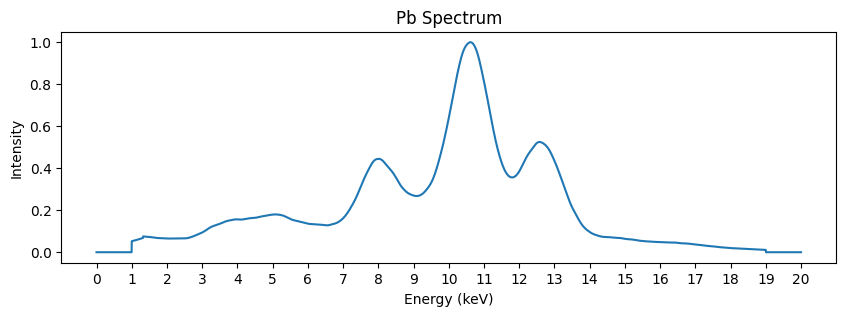

In [43]:
linspace = np.arange(4096)

N = 2000  # number of random samples

reference_pb = np.load(
    "data/objects/pigment_palette/pad_average_spectra_calibrated.npz",
    allow_pickle=True
)["spectrum"].item()["pb"]

reference_wood = np.load(
    "data/objects/pigment_palette/pad_average_spectra_calibrated.npz",
    allow_pickle=True
)["spectrum"].item()["wood"]

linspace = np.arange(4096)

# for _ in range(N):
#     spectrum = ArtificialTrainDataGenerator.generate_element_sample(
#         np.linspace(0, 20, 4096), "pb", sigma=0.7, mu_global_err=0.05, mu_local_err=0.05, use_cache=False
#     )

#     # Draw random parameters
#     sigmoid_left_max = np.random.uniform(0, 1)
#     sigmoid_right_min = np.random.uniform(0, sigmoid_left_max)
#     sigmoid_center = np.argmax(spectrum)
#     sigmoid_steepness = np.random.uniform(0.001, 0.01)
#     attenuation_strength = np.random.uniform(0.0, 1)

#     # Generate spectra
#     wood_spectrum = reference_wood


#     # Apply sigmoid window
#     sigmoid_window = custom_sigmoid_window(
#         x=linspace,
#         center=sigmoid_center,
#         steepness=sigmoid_steepness,
#         left_max=sigmoid_left_max,
#         right_min=sigmoid_right_min
#     )

#     # # Apply attenuation
#     attenuated_background = wood_spectrum * attenuation_strength
#     attenuated_background *= sigmoid_window

#     # # Combine + normalize
#     combined_spectrum_attenuated = spectrum + attenuated_background
#     normalized_combined_attenuated = combined_spectrum_attenuated / np.max(combined_spectrum_attenuated)

#     # # Plot with transparency
#     plt.plot(
#         # linspace
#         normalized_combined_attenuated,
#         color="blue",
#         alpha=0.01
#     )

plt.figure(figsize=(10, 3))
plt.plot(np.linspace(0, 20, 4096), reference_pb, label="Pb Spectrum")
plt.title(f"Pb Spectrum")
plt.xticks(np.arange(0, 21, 1))
plt.xlabel("Energy (keV)")
plt.ylabel("Intensity")
plt.savefig("pb_spectrum.svg", bbox_inches='tight', pad_inches=0.1)

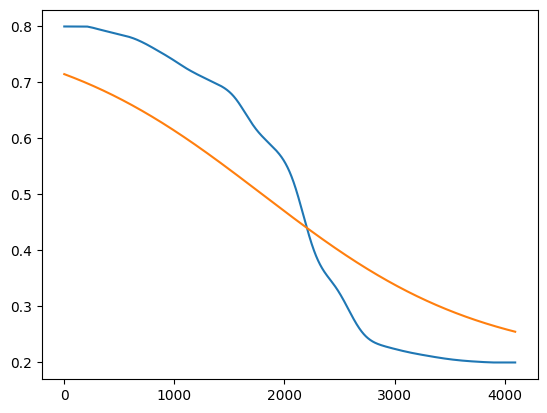

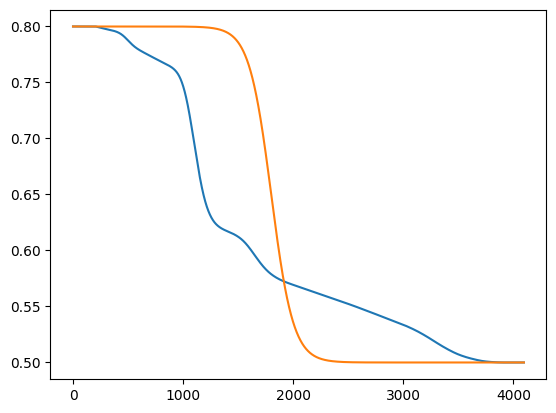

In [98]:
cumsum = np.cumsum(reference_pb[::-1])[::-1]

cumsum /= np.max(cumsum)
cumsum = 0.2 + cumsum * (0.8 - 0.2)

    # Apply sigmoid window
sigmoid_window = custom_sigmoid_window(
    x=linspace,
    center=1800,
    steepness=0.001,
    left_max=0.8,
    right_min=0.2
)

plt.plot(cumsum)
plt.plot(sigmoid_window)

plt.figure(123)

reference_cr = np.load(
    "data/objects/pigment_palette/pad_average_spectra_calibrated.npz",
    allow_pickle=True
)["spectrum"].item()["cr"]
cumsum = np.cumsum(reference_cr[::-1])[::-1]

cumsum /= np.max(cumsum)
cumsum = 0.5 + cumsum * (0.8 - 0.5)

sigmoid_center=1800,       
sigmoid_steepness=0.01,     
sigmoid_left_max=0.8,     
sigmoid_right_min=0.5

    # Apply sigmoid window
sigmoid_window = custom_sigmoid_window(
    x=linspace,
    center=1800,       
    steepness=0.01,     
    left_max=0.8,     
    right_min=0.5   
)

plt.plot(cumsum)
plt.plot(sigmoid_window)

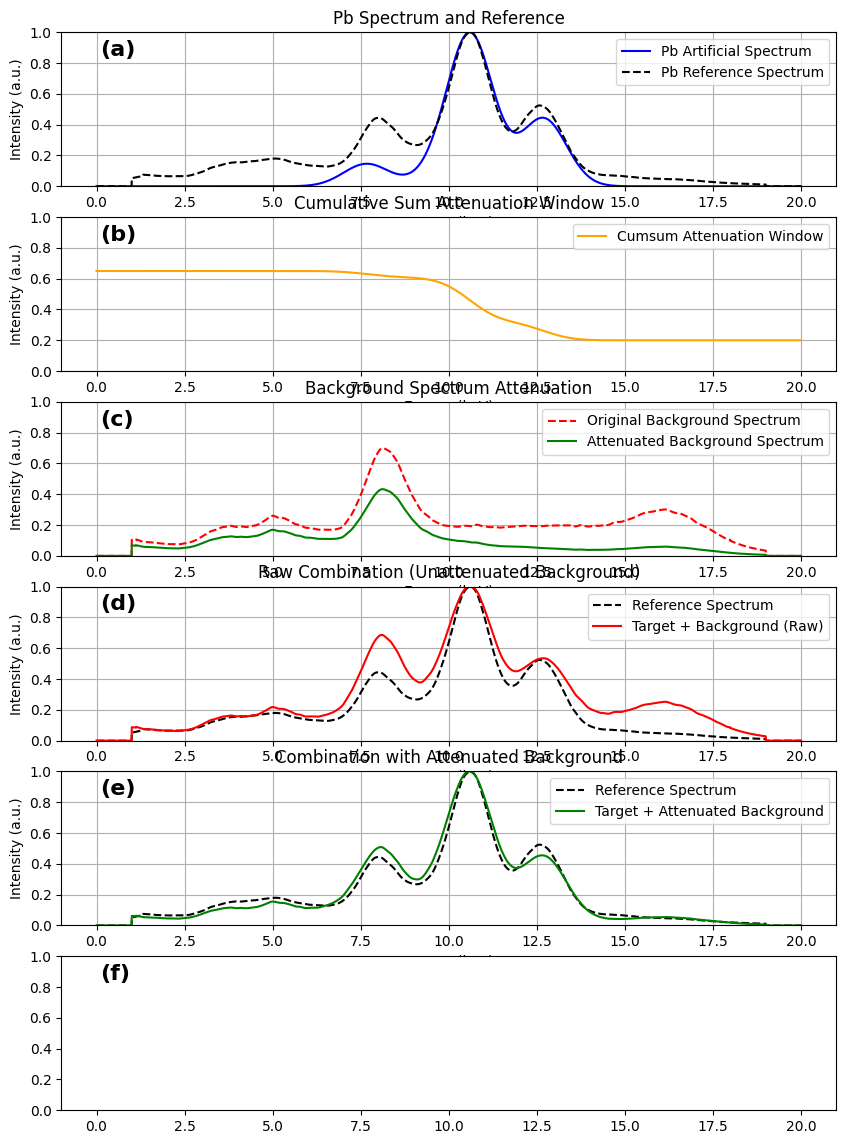

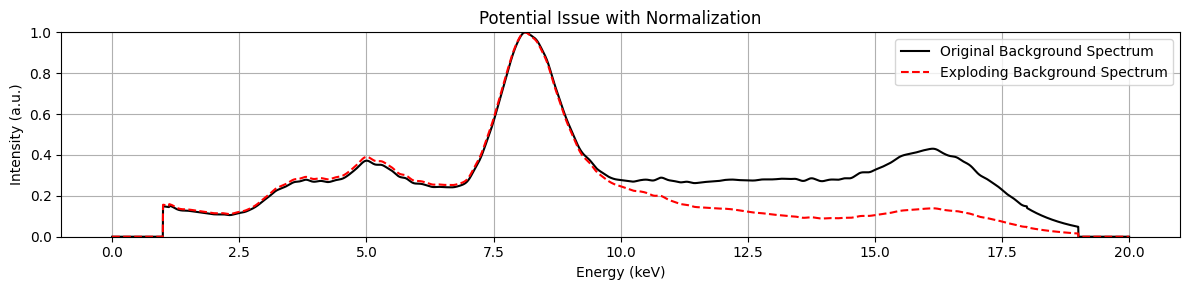

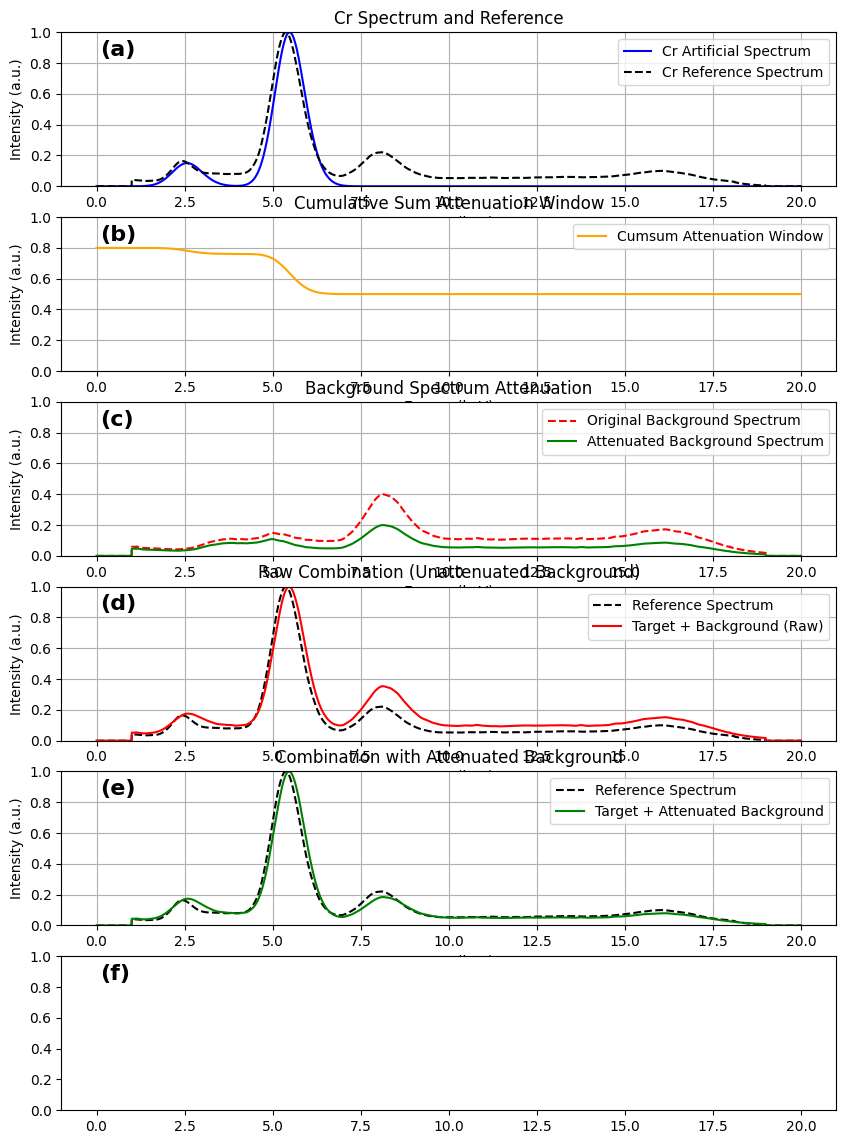

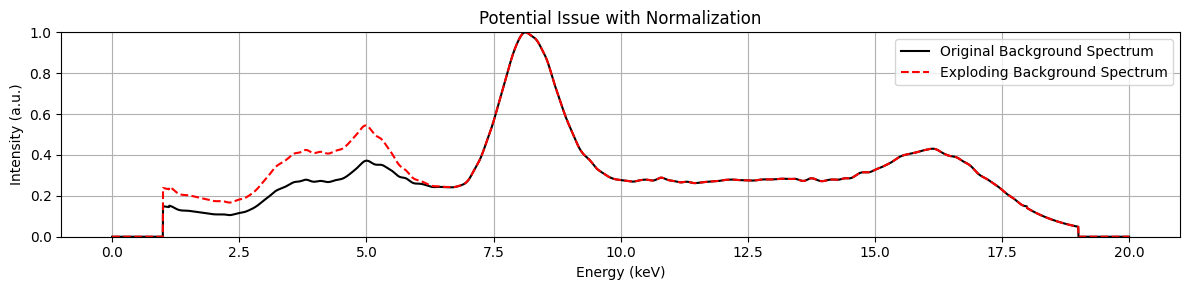

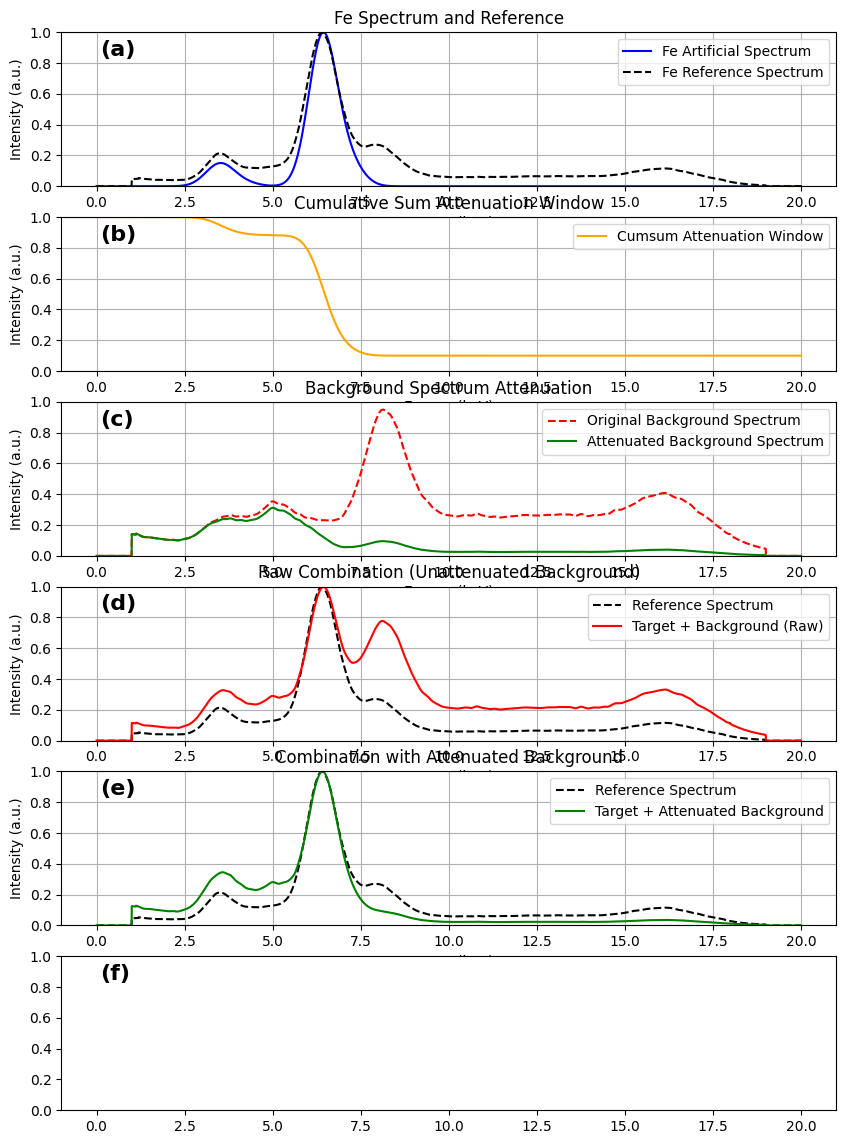

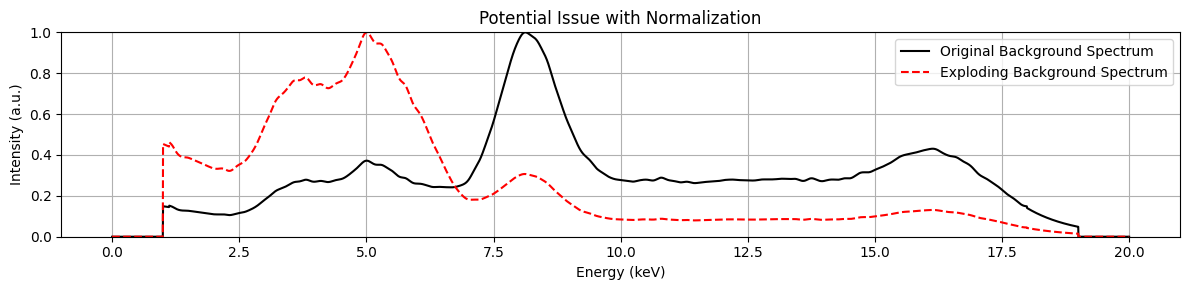

In [34]:
import numpy as np
import matplotlib.pyplot as plt


def cumsum_window(
    spectrum: np.ndarray,
    left_max: float = 1.0,
    right_min: float = 0.0
) -> np.ndarray:
    """
    Creates an attenuation window based on the cumulative sum of the spectrum.

    Args:
        spectrum: Input spectrum (1D array).
        left_max: Value at the left (low channel indices).
        right_min: Value at the right (high channel indices).

    Returns:
        A window array shaped by the cumulative sum of the spectrum.
    """
    # cumulative sum from right to left
    cumsum = np.cumsum(spectrum[::-1])[::-1]
    cumsum = cumsum / np.max(cumsum)  # normalize to [0, 1]

    # rescale to [right_min, left_max]
    return right_min + cumsum * (left_max - right_min)


def plot_spectrum_components_cumsum(
    target_spectrum,
    background_spectrum,
    reference_spectrum,
    element_label="Element",
    attenuation_strength=0.6,
    cumsum_left_max=1.0,
    cumsum_right_min=0.0
):
    num_channels = len(target_spectrum)
    channel_range = np.linspace(0, 20, num_channels)

    # Build attenuation window from cumulative sum of reference spectrum
    attenuation_window = cumsum_window(
        spectrum=target_spectrum,
        left_max=cumsum_left_max,
        right_min=cumsum_right_min
    )

    original_background = background_spectrum * attenuation_strength
    attenuated_background = original_background * attenuation_window

    combined_spectrum_raw = target_spectrum + original_background
    normalized_combined_raw = combined_spectrum_raw / np.max(combined_spectrum_raw)

    combined_spectrum_attenuated = target_spectrum + attenuated_background
    normalized_combined_attenuated = combined_spectrum_attenuated / np.max(combined_spectrum_attenuated)

    fig, axes = plt.subplots(6, 1, figsize=(10, 14), sharex=True)

    axes[0].plot(channel_range, target_spectrum, label=f'{element_label} Artificial Spectrum', color='blue')
    axes[0].plot(channel_range, reference_spectrum, linestyle='--', label=f'{element_label} Reference Spectrum', color='black')
    axes[0].set_title(f'{element_label} Spectrum and Reference')
    axes[0].set_ylabel("Intensity (a.u.)")
    axes[0].set_xlabel("Energy (keV)")
    axes[0].set_ylim(0, 1)
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(channel_range, attenuation_window, color='orange', label='Cumsum Attenuation Window')
    axes[1].set_title('Cumulative Sum Attenuation Window')
    axes[1].legend()
    axes[1].set_ylabel("Intensity (a.u.)")
    axes[1].set_xlabel("Energy (keV)")
    axes[1].set_ylim(0, 1)
    axes[1].grid(True)

    axes[2].plot(channel_range, original_background, color='red', linestyle='--', label='Original Background Spectrum')
    axes[2].plot(channel_range, attenuated_background, color='green', label='Attenuated Background Spectrum')
    axes[2].set_title('Background Spectrum Attenuation')
    axes[2].legend()
    axes[2].set_ylabel("Intensity (a.u.)")
    axes[2].set_xlabel("Energy (keV)")
    axes[2].set_ylim(0, 1)
    axes[2].grid(True)

    axes[3].plot(channel_range, reference_spectrum, color='black', linestyle='--', label='Reference Spectrum')
    axes[3].plot(channel_range, normalized_combined_raw, color='red', label='Target + Background (Raw)')
    axes[3].set_title('Raw Combination (Unattenuated Background)')
    axes[3].legend()
    axes[3].set_ylabel("Intensity (a.u.)")
    axes[3].set_xlabel("Energy (keV)")
    axes[3].set_ylim(0, 1)
    axes[3].grid(True)

    axes[4].plot(channel_range, reference_spectrum, color='black', linestyle='--', label='Reference Spectrum')
    axes[4].plot(channel_range, normalized_combined_attenuated, color='green', label='Target + Attenuated Background')
    axes[4].set_title('Combination with Attenuated Background')
    axes[4].legend()
    axes[4].set_ylabel("Intensity (a.u.)")
    axes[4].set_xlabel("Energy (keV)")
    axes[4].set_ylim(0, 1)
    axes[4].grid(True)

    plt.figure(figsize=(12, 3))
    tmp = attenuated_background
    tmp = tmp / np.max(tmp)
    plt.plot(channel_range, original_background / np.max(original_background), color='black', label='Original Background Spectrum')
    plt.plot(channel_range, tmp, color='red', linestyle='--', label='Exploding Background Spectrum')
    plt.title('Potential Issue with Normalization')
    plt.legend()
    plt.ylabel("Intensity (a.u.)")
    plt.xlabel("Energy (keV)")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.savefig("data/plots/potential_issue_normalization.svg", dpi=300, bbox_inches='tight', pad_inches=0.1)

    for i, ax in enumerate(axes):
        # Use string.ascii_lowercase to get letters 'a', 'b', 'c', ...
        import string
        label = f'({string.ascii_lowercase[i]})'
        
        # Add the text label to the top-left corner of the subplot
        ax.text(0.05, 0.95, label, transform=ax.transAxes,
                fontsize=16, fontweight='bold', va='top', ha='left')


    for ax in axes:
        ax.tick_params(labelbottom=True)

    plt.tight_layout()


# --- Example usage with your generator ---
wood_spectrum = np.load("data/objects/pigment_palette/pad_average_spectra_calibrated.npz", allow_pickle=True)["spectrum"].item()["wood"]

linspace = np.linspace(0, 20, 4096)
wood_spectrum = ArtificialTrainDataGenerator.generate_element_sample(
    linspace, "wood", sigma=0.65, mu_global_err=0.05, mu_local_err=0.05, use_cache=False
)

for element in ["pb", "cr", "fe"]:
    reference_spectrum = np.load("data/objects/pigment_palette/pad_average_spectra_calibrated.npz", allow_pickle=True)["spectrum"].item()[element]
    if element == "pb":
        spectrum = ArtificialTrainDataGenerator.generate_element_sample(
            linspace, element, sigma=0.65, mu_global_err=0.05, mu_local_err=0.05, use_cache=False
        )

        plot_spectrum_components_cumsum(
            target_spectrum=spectrum,
            background_spectrum=wood_spectrum,
            reference_spectrum=reference_spectrum,
            element_label=element.capitalize(),
            attenuation_strength=0.7,
            cumsum_left_max=0.65,    # instead of sigmoid_left_max
            cumsum_right_min=0.2    # instead of sigmoid_right_min
        )
        plt.savefig("data/plots/pb_spectrum_cumsum_calibration.svg", bbox_inches='tight', pad_inches=0.1)

    elif element == "cr":
        spectrum = ArtificialTrainDataGenerator.generate_element_sample(
            linspace, element, sigma=0.4, mu_global_err=0.05, mu_local_err=0.05, use_cache=False
        )

        plot_spectrum_components_cumsum(
            target_spectrum=spectrum,
            background_spectrum=wood_spectrum,
            reference_spectrum=reference_spectrum,
            element_label=element.capitalize(),
            attenuation_strength=0.4,
            cumsum_left_max=0.8,
            cumsum_right_min=0.5
        )
        plt.savefig("data/plots/cr_spectrum_cumsum_calibration.png", dpi=300)
    elif element == "fe":
        spectrum = ArtificialTrainDataGenerator.generate_element_sample(
            linspace, element, sigma=0.4, mu_global_err=0.05, mu_local_err=0.05, use_cache=False
        )

        plot_spectrum_components_cumsum(
            target_spectrum=spectrum,
            background_spectrum=wood_spectrum,
            reference_spectrum=reference_spectrum,
            element_label=element.capitalize(),
            attenuation_strength=0.95,
            cumsum_left_max=1,
            cumsum_right_min=0.1
        )
        plt.savefig("data/plots/ti_spectrum_cumsum_calibration.png", dpi=300)
